# SNN example in hls4ml

## imports

Before launching Jupyter, source your Xilinx tools, for example:

```bash
source /tools/Xilinx/Vitis/2024.1/settings64.sh
source /tools/Xilinx/Vivado/2024.1/settings64.sh
```

In [1]:
import copy
import json
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

import snntorch as snn

import hls4ml
import hls4ml.utils.torch
from hls4ml.utils.snntorch import SNNReadout
print(hls4ml.__file__)

try:
    import neurobench
    from neurobench.models import SNNTorchModel
    from neurobench.benchmarks import Benchmark
    from neurobench.metrics.static import Footprint, ConnectionSparsity
    from neurobench.metrics.workload import ClassificationAccuracy, ActivationSparsity, SynapticOperations
    HAS_NEUROBENCH = True
except Exception as err:
    HAS_NEUROBENCH = False
    print(f"[NeuroBench] import skipped: {err}")


def set_seed(seed: int = 0):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(0)

/home/b/Physics/hls4ml/hls4ml/__init__.py


## settings

I want a binary classifier that uses the membrane potentials on the final layer to perform classification.

In [2]:
set_seed(0)

output_dir = Path("examples/snn_example")
backend = "Vitis"
part = "xczu7ev-ffvc1156-2-e"
clock_period = 5
clock_uncertainty = "18%"

# general SNN precision
precision = "ap_fixed<8,4>"

# output mode
output_mode = "membrane"
decision_rule = "argmax_membrane"

# precision for spike readouts
readout_result_precision = "ap_int<8>"

# precision for membrane readouts
readout_membrane_precision = "ap_fixed<16,7>"
readout_membrane_beta = 1.0

timesteps = 50
n_trn = 2000
n_val = 300
n_tst = 300
batch_size = 64
n_epochs = 50
n_qat_epochs = 8
lr = 1e-3
qat_frac_bits = 7

hidden = 8
hidden_beta = 0.75
hidden_threshold = 1.0
if output_mode == "membrane":
    out_threshold = 1000.0
else:
    out_threshold = 0.5
#class_threshold = 5   # only needed for threshold decisions

READOUT_CONFIGS = [
    # {"name": "argmax_spike_count", "output_mode": "spike", "decision_rule": "argmax_spike_count"},
    # {"name": "first_to_threshold", "output_mode": "spike", "decision_rule": "first_to_threshold"},
    # {"name": "threshold_then_argmax", "output_mode": "spike", "decision_rule": "threshold_then_argmax"},
    # {"name": "binary_logit", "output_mode": "spike", "decision_rule": "binary_logit"},
    {"name": "argmax_membrane", "output_mode": "membrane", "decision_rule": "argmax_membrane"},
]

## data for the binary classification

In [3]:
def make_toy_dataset(n_samples: int, timesteps: int = 50, noise_std: float = 0.80, amp_jitter: float = 0.55):
    t = np.linspace(0.0, 1.0, timesteps, endpoint=False, dtype=np.float32)
    x = np.zeros((n_samples, timesteps, 2), dtype=np.float32)
    y = np.random.randint(0, 2, size=(n_samples,), dtype=np.int64)

    early = np.exp(-0.5 * ((t - 0.33) / 0.16) ** 2).astype(np.float32)
    late = np.exp(-0.5 * ((t - 0.67) / 0.16) ** 2).astype(np.float32)

    for i, label in enumerate(y):
        amp = 1.0 + np.random.uniform(-amp_jitter, amp_jitter)
        wave = 0.35 * np.sin(2 * np.pi * t).astype(np.float32)
        mix = np.random.uniform(-0.25, 0.25)

        if label == 0:
            ch0 = amp * ((0.95 + mix) * early - 0.70 * late + wave)
            ch1 = amp * (-0.55 * early + (0.25 - mix) * late - 0.40 * wave)
        else:
            ch0 = amp * (-0.55 * early + (0.25 + mix) * late + 0.40 * wave)
            ch1 = amp * ((0.95 - mix) * late - 0.70 * early - wave)

        x[i, :, 0] = ch0 + np.random.normal(0.0, noise_std, size=timesteps)
        x[i, :, 1] = ch1 + np.random.normal(0.0, noise_std, size=timesteps)

    x = np.clip(x, -2.0, 2.0).astype(np.float32)
    return x, y


x_trn, y_trn = make_toy_dataset(n_trn, timesteps)
x_val, y_val = make_toy_dataset(n_val, timesteps)
x_tst, y_tst = make_toy_dataset(n_tst, timesteps)

tx_trn = torch.from_numpy(x_trn).float()
ty_trn = torch.from_numpy(y_trn).long()
tx_val = torch.from_numpy(x_val).float()
ty_val = torch.from_numpy(y_val).long()
tx_tst = torch.from_numpy(x_tst).float()
ty_tst = torch.from_numpy(y_tst).long()

print(x_trn.shape, y_trn.shape)

(2000, 50, 2) (2000,)


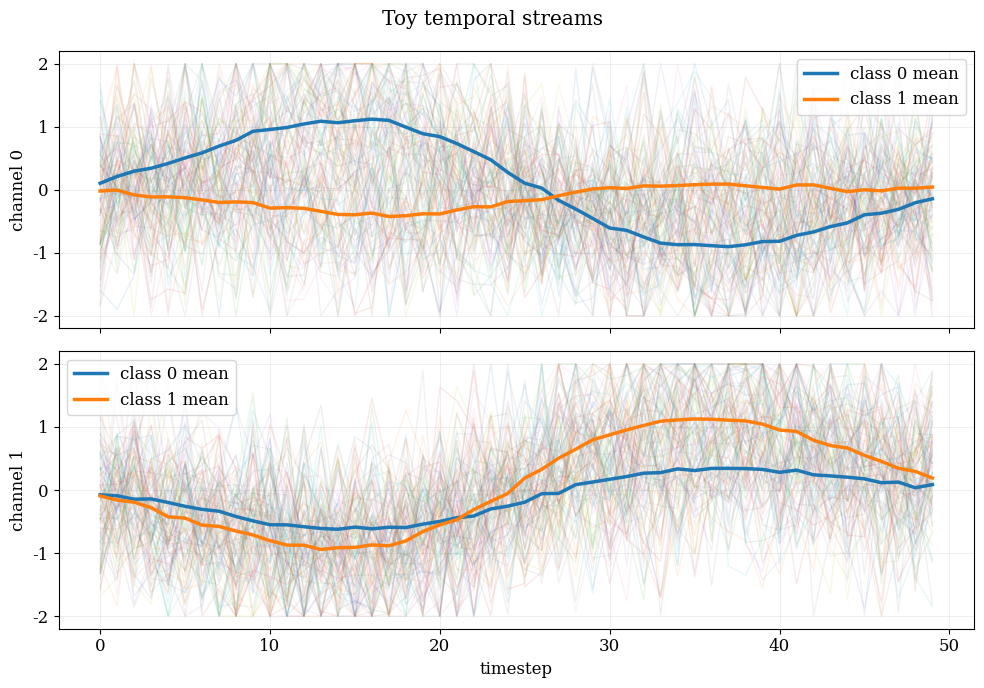

In [4]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "font.size": 12,
})

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
t = np.arange(timesteps)
for ch, ax in enumerate(axes):
    for seq in x_trn[y_trn == 0][:50]:
        ax.plot(t, seq[:, ch], alpha=0.10, linewidth=1.0)
    for seq in x_trn[y_trn == 1][:50]:
        ax.plot(t, seq[:, ch], alpha=0.10, linewidth=1.0)
    ax.plot(t, x_trn[y_trn == 0, :, ch].mean(axis=0), linewidth=2.5, label="class 0 mean")
    ax.plot(t, x_trn[y_trn == 1, :, ch].mean(axis=0), linewidth=2.5, label="class 1 mean")
    ax.set_ylabel(f"channel {ch}")
    ax.grid(alpha=0.20)
    ax.legend(loc="best")
axes[-1].set_xlabel("timestep")
fig.suptitle("Toy temporal streams")
fig.tight_layout()

## define SNN

The output of the SNN should use `SNNReadout`.  SNNs are time-series, and the `SNNReadout` module takes care of the decision after the signal has finished.

In [5]:
class ReadoutSNN(nn.Module):
    def __init__(self, decision_rule="argmax_membrane", output_mode="membrane", readout_beta=1.0):
        super().__init__()

        # linear layer input
        self.fc1 = nn.Linear(2, hidden)

        # spiking neuron
        self.if1 = snn.Leaky(
            beta=hidden_beta,
            threshold=hidden_threshold,
            learn_beta=True,
            reset_mechanism="subtract",
        )

        # linear layer
        self.fc2 = nn.Linear(hidden, 2)

        # final spiking neuron if we use spike outputs, no neuron needed if we use membrane outputs
        if output_mode != "membrane":
            self.if2 = snn.Leaky(
                beta=1.0,
                threshold=out_threshold,
                learn_beta=False,
                reset_mechanism="subtract",
            )

        # readout layer
        self.readout = SNNReadout(
            n_classes=2,
            window_size=timesteps,
            decision_rule=decision_rule,
            #class_threshold=class_threshold,
            output_mode=output_mode,
            beta=readout_beta,
        )

    def forward(self, x_t):
        # linear
        x_t = self.fc1(x_t)
        # spike
        spk1, _ = self.if1(x_t)
        # linear
        x_t = self.fc2(spk1)
        # straight to readout if using membrane outputs
        if self.readout.output_mode == "membrane":
            # readout
            return self.readout(x_t)
        # convert to spikes with spiking neuron
        spk2, _ = self.if2(x_t)
        # readout
        return self.readout(spk2)


model = ReadoutSNN(decision_rule=decision_rule, output_mode=output_mode)
model

ReadoutSNN(
  (fc1): Linear(in_features=2, out_features=8, bias=True)
  (if1): Leaky()
  (fc2): Linear(in_features=8, out_features=2, bias=True)
  (readout): SNNReadout()
)

## helper functions

In [6]:
# reset snn state
def reset_snn_state(net):
    for module in net.modules():
        if hasattr(module, "reset_hidden"):
            module.reset_hidden()
        elif hasattr(module, "reset_mem"):
            module.reset_mem()

# straight-through estimator for qat
def fake_quant_ste(x, frac_bits=4):
    scale = float(2**frac_bits)
    q = torch.round(x * scale) / scale
    return x + (q - x).detach()

# runs series data through the snn
# uses the ste if we are running qat
def run_sequence(net, x_seq, qat=False, frac_bits=4):
    reset_snn_state(net)
    outs = []
    for step in range(x_seq.shape[1]):
        x_t = x_seq[:, step, :]
        if qat:
            x_t = fake_quant_ste(x_t, frac_bits)
        outs.append(net(x_t))
    return torch.stack(outs, dim=1)  # [batch, timesteps, classes]


# this implements the readout as it is done in hls4snn
def reduce_readout_reference(outs, output_mode="membrane", decision_rule="argmax_membrane", beta=1.0):
    if output_mode == "membrane":
        mem = torch.zeros_like(outs[:, 0, :])
        for step in range(outs.shape[1]):
            mem = beta * mem + outs[:, step, :]
        return mem
    return outs.sum(dim=1)

# predict output for accuracy metric
def predict_from_readout_values(values, decision_rule="argmax_membrane"):
    if decision_rule == "binary_logit":
        return (values[:, 1] - values[:, 0] > 0).long()
    return values.argmax(dim=1).long()

## snn model training

In [7]:
# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# simple scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=n_epochs + n_qat_epochs,
    eta_min=1e-4,
)

# ce loss
loss_fn = nn.CrossEntropyLoss()

# data loader for trn data
trn_loader = DataLoader(TensorDataset(tx_trn, ty_trn), batch_size=batch_size, shuffle=True)

In [8]:
# we loop through regular + qat-aware epochs
for epoch in range(n_epochs + n_qat_epochs):
    
    model.train()

    # qat flag
    use_qat = epoch >= n_epochs

    # loop through batches
    for xb, yb in trn_loader:
        # zero the grads
        optimizer.zero_grad()
        # run series data through the snn
        outs = run_sequence(model, xb, qat=use_qat, frac_bits=qat_frac_bits)
        # convert to readout
        logits = reduce_readout_reference(
            outs,
            output_mode=model.readout.output_mode,
            decision_rule=model.readout.decision_rule,
            beta=float(model.readout.beta),
        )
        # compute loss
        loss = loss_fn(logits, yb)

        # mild regularization keeps the learned beta small and quantization-friendly.
        if hasattr(model.if1, "beta"):
            loss = loss + 1e-3 * torch.mean(model.if1.beta**2)

        # compute and update weights
        loss.backward()
        optimizer.step()
        
    # schedule lr
    scheduler.step()

    # quantize learned beta after each qat epoch
    if use_qat and hasattr(model.if1, "beta"):
        scale = float(2**qat_frac_bits)
        with torch.no_grad():
            model.if1.beta.data = torch.round(model.if1.beta.data * scale) / scale

    # output stats
    if epoch == 0 or (epoch + 1) % 5 == 0:
        model.eval()
        with torch.no_grad():
            trn_values = reduce_readout_reference(
                run_sequence(model, tx_trn[:512]),
                output_mode=model.readout.output_mode,
                decision_rule=model.readout.decision_rule,
                beta=float(model.readout.beta),
            )
            val_values = reduce_readout_reference(
                run_sequence(model, tx_val),
                output_mode=model.readout.output_mode,
                decision_rule=model.readout.decision_rule,
                beta=float(model.readout.beta),
            )
            trn_pred = predict_from_readout_values(trn_values, model.readout.decision_rule)
            val_pred = predict_from_readout_values(val_values, model.readout.decision_rule)
            trn_acc = (trn_pred == ty_trn[:512]).float().mean().item()
            val_acc = (val_pred == ty_val).float().mean().item()
        phase = "QAT" if use_qat else "FP"
        print(f"[{phase} epoch {epoch + 1:03d}] train_acc={trn_acc:.3f} val_acc={val_acc:.3f}")

[FP epoch 001] train_acc=0.650 val_acc=0.637
[FP epoch 005] train_acc=0.930 val_acc=0.910
[FP epoch 010] train_acc=0.982 val_acc=0.970
[FP epoch 015] train_acc=0.986 val_acc=0.977
[FP epoch 020] train_acc=0.992 val_acc=0.977
[FP epoch 025] train_acc=0.992 val_acc=0.977
[FP epoch 030] train_acc=0.992 val_acc=0.973
[FP epoch 035] train_acc=0.996 val_acc=0.973
[FP epoch 040] train_acc=0.992 val_acc=0.983
[FP epoch 045] train_acc=0.990 val_acc=0.980
[FP epoch 050] train_acc=0.990 val_acc=0.987
[QAT epoch 055] train_acc=0.992 val_acc=0.987


Now run on the test data.

In [9]:
model.eval()
with torch.no_grad():
    tst_values = reduce_readout_reference(
        run_sequence(model, tx_tst),
        output_mode=model.readout.output_mode,
        decision_rule=model.readout.decision_rule,
        beta=float(model.readout.beta),
    )
    tst_pred = predict_from_readout_values(tst_values, model.readout.decision_rule)
    tst_acc = (tst_pred == ty_tst).float().mean().item()

print(f"Torch {model.readout.output_mode}/{model.readout.decision_rule} test accuracy = {tst_acc:.4f}")

Torch membrane/argmax_membrane test accuracy = 0.9767


## hls config

Here we generate the config file for the HLS conversion.

Note:  During PyTorch conversion, the fixed `readout.window_size` is propagated to every converted IF/LIF neuron. The generated C++ uses that value as the fixed sequence boundary for state reset.

In [10]:
def make_hls_config(step_model):

    cfg = hls4ml.utils.config_from_pytorch_model(
        step_model,
        input_shape=(2,),
        granularity="name",
        backend=backend,
        default_precision=precision,
    )

    cfg["Model"]["ReuseFactor"] = 1
    cfg["Model"].setdefault("Precision", {})["default"] = precision

    for layer_name, layer_cfg in cfg.get("LayerName", {}).items():
        layer_precision = layer_cfg.setdefault("Precision", {})

        for key in ("result", "accum", "weight", "bias"):
            layer_precision[key] = precision

        if layer_name in {"if1", "if2"}:
            for key in ("beta", "threshold", "membrane"):
                layer_precision[key] = precision
            layer_cfg["beta_t"] = precision
            layer_cfg["threshold_t"] = precision
            layer_cfg["membrane_t"] = precision

        if layer_name == "readout":
            layer_precision["result"] = readout_result_precision
            layer_precision["membrane"] = readout_membrane_precision
            layer_cfg["membrane_t"] = readout_membrane_precision

    return cfg


hls_config = make_hls_config(model)

print(json.dumps(hls_config["Model"], indent=2, default=str))
print("\nLayer entries:")
for name, cfg in hls_config.get("LayerName", {}).items():
    print(f"  {name:10s}: {sorted(cfg.keys())}")

{
  "Precision": {
    "default": "ap_fixed<8,4>"
  },
  "ReuseFactor": 1,
  "ChannelsLastConversion": "full",
  "TransposeOutputs": false,
  "Strategy": "Latency",
  "BramFactor": 1000000000,
  "TraceOutput": false
}

Layer entries:
  x_t       : ['Precision', 'Trace']
  fc1       : ['Precision', 'ReuseFactor', 'Trace']
  if1       : ['Precision', 'Trace', 'beta_t', 'membrane_t', 'threshold_t']
  fc2       : ['Precision', 'ReuseFactor', 'Trace']
  readout   : ['Precision', 'StateResetPolicy', 'Trace', 'membrane_t']


## convert to hls

In [11]:
output_dir = Path('examples/snn_example')
proj_name = 'test'
hls_dir = output_dir / proj_name
hls_dir.mkdir(parents=True, exist_ok=True)

hls_model = hls4ml.converters.convert_from_pytorch_model(
    model,
    output_dir=str(hls_dir),
    project_name=proj_name,
    backend=backend,
    io_type="io_stream",
    hls_config=hls_config,
    part=part,
    clock_period=clock_period,
    clock_uncertainty=clock_uncertainty,
)
hls_model.write()

Interpreting Model ...
Topology:
Layer name: fc1, layer type: Dense, input shape: [[None, 2]]
Layer name: if1, layer type: LIFNeuron, input shape: [[None, 8]]
Layer name: fc2, layer type: Dense, input shape: [[None, 8]]
Layer name: readout, layer type: SNNReadout, input shape: [[None, 2]]


## get hls benchmark

Compile immediately before evaluating full sequences. The compiled SNN state persists between calls, and the fixed-window reset occurs after exactly `timesteps` calls. If HLS accuracy is much lower than the PyTorch reference, first check that the generated `parameters.h` contains `window_size` in the IF/LIF config and that the fixed-point precision is not too narrow.

In [12]:
def _as_scalar(y_step):
    if isinstance(y_step, tuple):
        y_step = y_step[0]
    if isinstance(y_step, dict):
        y_step = y_step[next(iter(y_step.keys()))]
    return float(np.asarray(y_step).reshape(-1)[0])


def assert_fixed_window_reset_was_generated(hls_dir, window_size):
    parameters_h = hls_dir / "firmware" / "parameters.h"
    text = parameters_h.read_text()
    expected = f"static const unsigned window_size = {window_size};"
    if expected not in text:
        raise RuntimeError(
            f"{parameters_h} does not contain {expected!r}. Re-run the conversion/write cell before compiling."
        )


def predict_hls_sequences(hls_model, x_seq, timesteps):
    """Run one fixed-window sequence at a time through the stateful HLS model."""
    values = []
    for sample in range(x_seq.shape[0]):
        last = None
        for step in range(timesteps):
            x_step = x_seq[sample, step, :].astype(np.float32)[None, :]
            last = _as_scalar(hls_model.predict(x_step))
        values.append(last)
    return np.asarray(values, dtype=np.float32)


In [13]:
#assert_fixed_window_reset_was_generated(hls_dir, timesteps)

# Compile immediately before sequence evaluation. Avoid making stray single-timestep
# predict calls before this loop; the compiled SNN state is persistent between calls.
hls_model.compile()
t0 = time.perf_counter()
raw = predict_hls_sequences(hls_model, x_tst, timesteps)

if model.readout.decision_rule == "binary_logit":
    preds = (raw > 0).astype(np.int64)
else:
    preds = np.rint(raw).astype(np.int64)

elapsed = time.perf_counter() - t0
print("accuracy: ", float(np.mean(preds == y_tst)))
print("throughput_samples_per_s: ", float(x_tst.shape[0] / elapsed) if elapsed > 0 else 0.0)

accuracy:  0.95
throughput_samples_per_s:  639.4442680253416


## neurobench

The model defined as it is here, is also compatiable with neurobench.  We just need some helper functions.

In [14]:
class NeuroBenchStepAdapter(nn.Module):
    def __init__(self, step_model):
        super().__init__()
        self.step_model = step_model

    def forward(self, x_t):
        y = self.step_model(x_t)
        if isinstance(y, tuple):
            return y
        return y, None

    def reset(self):
        reset_snn_state(self.step_model)


class NeuroBenchReadoutPostprocessor:
    def __init__(self, decision_rule="argmax_spike_count", class_threshold=5):
        self.decision_rule = decision_rule
        self.class_threshold = class_threshold

    def __call__(self, preds):
        if isinstance(preds, tuple):
            preds = preds[0]
        if isinstance(preds, np.ndarray):
            preds = torch.from_numpy(preds)
        if not torch.is_tensor(preds):
            preds = torch.as_tensor(preds)

        counts = preds.sum(dim=1) if preds.ndim == 3 else preds

        if self.decision_rule == "binary_logit":
            return (counts[:, 1] - counts[:, 0] > 0).long()
        if self.decision_rule == "argmax_spike_count":
            return counts.argmax(dim=1).long()

        reached = counts >= self.class_threshold
        has_reached = reached.any(dim=1)
        first_reached = reached.float().argmax(dim=1)
        fallback = counts.argmax(dim=1)
        return torch.where(has_reached, first_reached, fallback).long()

In [15]:
if HAS_NEUROBENCH:
    model.eval()
    test_loader = DataLoader(TensorDataset(tx_tst.float(), ty_tst.long()), batch_size=64, shuffle=False)

    nb_model = SNNTorchModel(NeuroBenchStepAdapter(model))
    preprocessors = []
    postprocessors = [
        NeuroBenchReadoutPostprocessor(
            decision_rule=model.readout.decision_rule,
            class_threshold=model.readout.class_threshold,
        )
    ]
    static_metrics = [Footprint, ConnectionSparsity]
    workload_metrics = [ClassificationAccuracy, ActivationSparsity, SynapticOperations]

    benchmark = Benchmark(
        nb_model,
        test_loader,
        preprocessors,
        postprocessors,
        [static_metrics, workload_metrics],
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    results = benchmark.run(device=device)
    print(json.dumps(results, indent=2))
else:
    print("NeuroBench is not installed in this environment.")

Running benchmark


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 32.28it/s]

{
  "Footprint": 9788,
  "ConnectionSparsity": 0.0,
  "ClassificationAccuracy": 0.976666669845581,
  "ActivationSparsity": 0.7599916666666667,
  "SynapticOperations": {
    "Effective_MACs": 800.0,
    "Effective_ACs": 192.00666666666666,
    "Dense": 1600.0
  }
}


## full hls build

In [16]:
report = hls_model.build(
    reset=True,
    csim=True,
    synth=True,
    cosim=True,
    validation=True,
    export=True,
    vsynth=True,
)
print(report)


****** vitis-run v2024.1 (64-bit)
  **** SW Build 5074859 on 2024-05-20-23:21:20
  **** Start of session at: Tue May  5 18:06:10 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

INFO: [vitis-run 82-31] Launching vitis_hls: vitis_hls -nolog -run tcl -f /home/b/Physics/hls4ml/examples/snn_example/test/build_prj.tcl -work_dir /home/b/Physics/hls4ml/examples/snn_example/test

****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2024.1 (64-bit)
  **** SW Build 5069499 on May 21 2024
  **** IP Build 5075265 on Wed May 22 21:45:21 MDT 2024
  **** SharedData Build 5076995 on Wed May 22 18:29:18 MDT 2024
  **** Start of session at: Tue May  5 18:06:11 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

source /tools/Xilinx/Vitis_HLS/2024.1/scripts/vitis_hls/hls.tcl -notrace
INFO: [HLS 200-10] For us